# Evaluation: Response-Aware Dialogue Caching

In this notebook, we analyse the empirical results of the caching experiments (Phase 1 of the artefact evaluation). The goal is to validate the mechanics of the *Response-Aware Dialogue Caching* and quantify the operational savings generated by the growing dialogue tree.

### Experimental Setup
The dataset originates from a simulated CI/CD environment. The simulation executed **30 dialogue repetitions** across **5 distinct cached roots**.

The setup used the following deterministic hyperparameters:
* **Context Expansion:** `alpha = 2`, `beta = 3`, `dir = below`
* **Validation:** `safeguard = True`

### Data Structure & Organisation
Each root is assigned a unique identifier (`root_id`). This ID serves as the primary key connecting all associated data files, which share the same UID in their filenames across different directories:
* **`tree/`**: Contains a `.json` file storing the recursive branches of the cache tree that grow from this root.
* **`conversations/`**: Contains the `.log` and `.jsonl` files of the generated multi-turn conversations.
* **`measurements/`**: Contains a `.jsonl` file logging the exact turn-by-turn metrics, including latency, token consumption, semantic similarity scores, and the Conversation Validator's (CV) accept/reject decisions.

**Methodological Note:** During the simulation, the system always retrieved the cached node with the highest semantic similarity *without* enforcing a lower bound ($\tau$). For every interaction, the exact similarity score, the final accept or reject decision by the Conversation Validator (CV), execution latencies, and token consumption were logged. This continuous logging approach allows us to retrospectively simulate and evaluate the system's behaviour across various threshold limits in this notebook.

### Objectives of this Analysis

This notebook focuses on two core analyses:

1. **Similarity Threshold Calibration (Confusion Matrix)**
   By matching the logged similarity scores against the actual CV decisions, we construct a confusion matrix for varying $\tau$ values. We investigate the ratio of Safe Hits (True Positives) to Dangerous Hits (False Positives) to identify the empirical sweet spot that maximises cache utilisation while minimising costly CV rejections within our experimental setup.

2. **Cache Efficiency Over Time (Growth Plots)**
   We visualise the temporal development of the cache over the 30 iterations. Using the logged latency and token metrics, we demonstrate how the continuous expansion of the dialogue tree progressively reduces the need for fresh generations. These plots aim to show how quickly the system reaches a stable state and confirm whether the caching mechanism delivers tangible operational value.

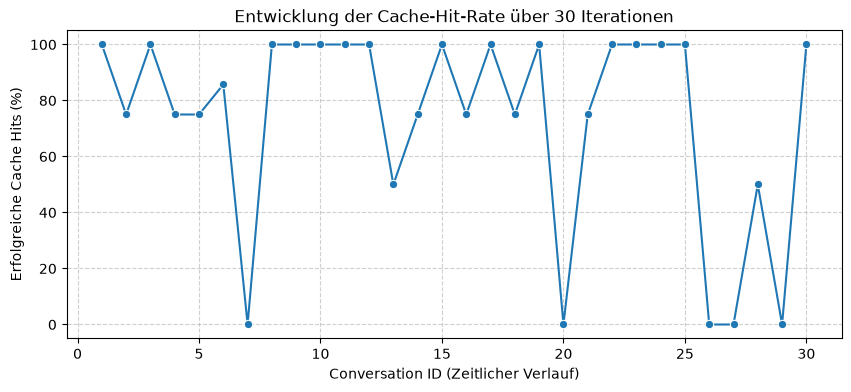

/tmp/ipykernel_80794/3160359157.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cache, x='validator_passed', y='highest_sim', palette="Set2")


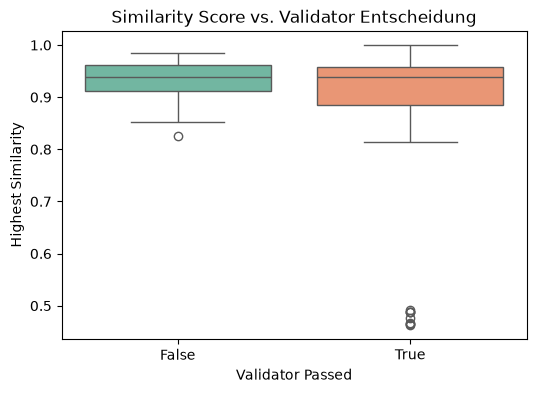

/tmp/ipykernel_80794/3160359157.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=candidate_stats.index, y=candidate_stats['mean'], palette="Blues_d")


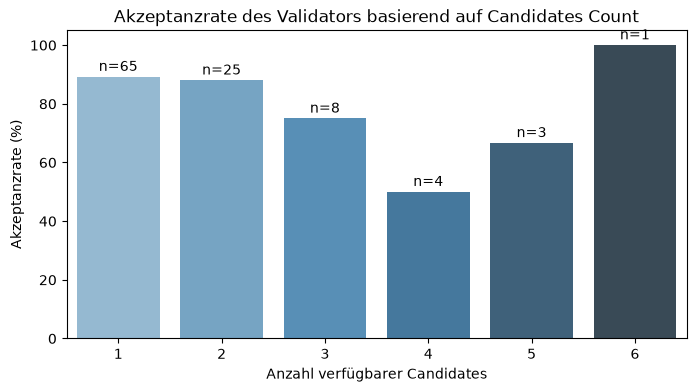


--- Confusion Matrix über verschiedene Tau-Werte ---


,Tau,TP (Safe Hit),FP (Dangerous),FN (Missed Eff),TN (Bypass)
0,0.85,74,14,17,1
1,0.90,64,11,27,4
2,0.93,55,9,36,6
3,0.95,32,5,59,10
4,0.97,5,3,86,12


In [7]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Daten laden (Passe den Dateipfad an deine Datei an)
data = []
with open("measurements/d309b277-6b25-4e33-a954-b8cdc7e288cf.jsonl", "r") as f: # 392c9cc7-f4c1-4529-94fc-2a1f59ced3cd
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)

# Nur Daten betrachten, bei denen ein Cache-Hit überhaupt möglich war
df_cache = df[df['cache_available'] == True].copy()

# -------------------------------------------------------------------
# Plot 1: Entwicklung der Cache-Akzeptanz über die Zeit (Conversations)
# -------------------------------------------------------------------
plt.figure(figsize=(10, 4))
# Wir berechnen, wie viel Prozent der Turns pro Conversation gecached wurden
cache_trend = df.groupby('conversation_id')['cache_accepted_and_used'].mean() * 100
sns.lineplot(x=cache_trend.index, y=cache_trend.values, marker="o")
plt.title("Entwicklung der Cache-Hit-Rate über 30 Iterationen")
plt.xlabel("Conversation ID (Zeitlicher Verlauf)")
plt.ylabel("Erfolgreiche Cache Hits (%)")
plt.ylim(-5, 105)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# -------------------------------------------------------------------
# Plot 2: Einfluss der semantischen Ähnlichkeit auf die CV-Akzeptanz
# -------------------------------------------------------------------
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_cache, x='validator_passed', y='highest_sim', palette="Set2")
plt.title("Similarity Score vs. Validator Entscheidung")
plt.xlabel("Validator Passed")
plt.ylabel("Highest Similarity")
plt.show()

# -------------------------------------------------------------------
# Plot 3: Einfluss der Anzahl an Candidates auf die CV-Akzeptanz
# -------------------------------------------------------------------
plt.figure(figsize=(8, 4))
candidate_stats = df_cache.groupby('candidates_count')['validator_passed'].agg(['mean', 'count'])
candidate_stats['mean'] = candidate_stats['mean'] * 100 # In Prozent
sns.barplot(x=candidate_stats.index, y=candidate_stats['mean'], palette="Blues_d")
plt.title("Akzeptanzrate des Validators basierend auf Candidates Count")
plt.xlabel("Anzahl verfügbarer Candidates")
plt.ylabel("Akzeptanzrate (%)")
for index, row in candidate_stats.iterrows():
    plt.text(index-1, row['mean']+2, f"n={int(row['count'])}", ha='center')
plt.show()

# -------------------------------------------------------------------
# Analyse 4: Confusion Matrix für verschiedene Similarity Thresholds
# -------------------------------------------------------------------
thresholds = [0.85, 0.90, 0.93, 0.95, 0.97]
results = []

for tau in thresholds:
    # True Positives: Sim >= tau UND Validator sagt True
    tp = len(df_cache[(df_cache['highest_sim'] >= tau) & (df_cache['validator_passed'] == True)])
    # False Positives: Sim >= tau ABER Validator sagt False (Dangerous Hit!)
    fp = len(df_cache[(df_cache['highest_sim'] >= tau) & (df_cache['validator_passed'] == False)])
    # False Negatives: Sim < tau OBWOHL Validator True gesagt hätte (Missed Efficiency)
    fn = len(df_cache[(df_cache['highest_sim'] < tau) & (df_cache['validator_passed'] == True)])
    # True Negatives: Sim < tau UND Validator sagt False (Correct Bypass)
    tn = len(df_cache[(df_cache['highest_sim'] < tau) & (df_cache['validator_passed'] == False)])
    
    results.append({
        "Tau": tau,
        "TP (Safe Hit)": tp,
        "FP (Dangerous)": fp,
        "FN (Missed Eff)": fn,
        "TN (Bypass)": tn
    })

df_conf = pd.DataFrame(results)
print("\n--- Confusion Matrix über verschiedene Tau-Werte ---")
display(df_conf)